## Collect & Prepare Your Own Documents

Task:

1. Create a folder named my_docs/.
2. Place at least 3 text-based files in it — .txt, .md, or extracted .pdf text.
  
Examples:
  - A research paper summary you wrote
  - A blog article about AI or sustainability
  - Course notes or company reports

3. Load them into Python.

In [1]:
import os

folder = "my_docs"
os.makedirs(folder, exist_ok=True)
# TODO: Load your own files
# Verify their data loaded properly.
# Write a few lines describing what kind of documents they chose and why

# If folder is empty, create 3 simple text documents for this exercise
if len(os.listdir(folder)) == 0:
    with open(os.path.join(folder, "rag_notes.txt"), "w", encoding="utf-8") as f:
        f.write("""
RAG stands for Retrieval-Augmented Generation. 
It combines information retrieval with text generation.
RAG helps language models answer using external documents instead of only using stored model knowledge.
This reduces hallucination and makes answers more grounded.
""")

    with open(os.path.join(folder, "ai_ethics.txt"), "w", encoding="utf-8") as f:
        f.write("""
AI ethics focuses on fairness, privacy, transparency, accountability, and bias.
Ethical AI systems should avoid discrimination and explain their decisions clearly.
AI models can create risks when they are trained on biased or poor-quality data.
""")

    with open(os.path.join(folder, "transformers.txt"), "w", encoding="utf-8") as f:
        f.write("""
Transformers are deep learning models used in modern NLP.
They use self-attention to understand relationships between words in a sequence.
BERT, GPT, and many large language models are based on transformer architecture.
""")

documents = []

for file in os.listdir(folder):
    if file.endswith((".txt", ".md")):
        with open(os.path.join(folder, file), "r", encoding="utf-8") as f:
            documents.append(f.read())

print(f"Loaded {len(documents)} documents.")
print(documents[0][:300])

Loaded 3 documents.

AI ethics focuses on fairness, privacy, transparency, accountability, and bias.
Ethical AI systems should avoid discrimination and explain their decisions clearly.
AI models can create risks when they are trained on biased or poor-quality data.



## Chunk Your Texts

**Goal**: Break long text into manageable pieces for retrieval.

In [2]:
def chunk_text(text, chunk_size=200):
    words = text.split()
    chunks = []

    for i in range(0, len(words), chunk_size):
        chunk = " ".join(words[i:i + chunk_size])
        chunks.append(chunk)

    return chunks

# TODO: Apply chunking to all your documents
# Try different chunk sizes (100, 200, 400).
# Which size produced more relevant retrievals later? Why?

chunks = []

for doc in documents:
    chunks.extend(chunk_text(doc, chunk_size=200))

print("Total chunks created:", len(chunks))

for i, chunk in enumerate(chunks, start=1):
    print(f"\nChunk {i}:")
    print(chunk[:300])

Total chunks created: 3

Chunk 1:
AI ethics focuses on fairness, privacy, transparency, accountability, and bias. Ethical AI systems should avoid discrimination and explain their decisions clearly. AI models can create risks when they are trained on biased or poor-quality data.

Chunk 2:
RAG stands for Retrieval-Augmented Generation. It combines information retrieval with text generation. RAG helps language models answer using external documents instead of only using stored model knowledge. This reduces hallucination and makes answers more grounded.

Chunk 3:
Transformers are deep learning models used in modern NLP. They use self-attention to understand relationships between words in a sequence. BERT, GPT, and many large language models are based on transformer architecture.


## Build Your Own Retriever (Semantic)

**Goal**: Retrieve the most relevant chunks using embeddings.

In [3]:
from sentence_transformers import SentenceTransformer, util
import torch

embedder = SentenceTransformer("all-MiniLM-L6-v2")
# TODO: Embed your chunks
chunk_embeddings = embedder.encode(chunks, convert_to_tensor=True)

def retrieve_chunks(query, k=2):
    query_embed = embedder.encode(query, convert_to_tensor=True)

    scores = util.cos_sim(query_embed, chunk_embeddings)[0]

    top_k = torch.topk(scores, k)

    retrieved_chunks = []

    for index in top_k.indices:
        retrieved_chunks.append(chunks[index])

    return retrieved_chunks


print(retrieve_chunks("What is discussed about AI ethics?", k=2))

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6865.75it/s]


['AI ethics focuses on fairness, privacy, transparency, accountability, and bias. Ethical AI systems should avoid discrimination and explain their decisions clearly. AI models can create risks when they are trained on biased or poor-quality data.', 'Transformers are deep learning models used in modern NLP. They use self-attention to understand relationships between words in a sequence. BERT, GPT, and many large language models are based on transformer architecture.']


## Connect Retrieval with Generation

**Goal**: Use retrieved chunks as context for text generation.

In [4]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="distilgpt2",
    max_new_tokens=120,
    temperature=0.3,
    pad_token_id=50256
)

def mini_rag(query, k=2):
    retrieved = retrieve_chunks(query, k)
    context = "\n".join(retrieved)

    prompt = f"""
Use the following context to answer the question.

Context:
{context}

Question:
{query}

Answer:
"""

    result = generator(prompt)[0]["generated_text"]
    return result

# TODO: Try 2–3 questions based on your own documents
#Observe how the generator uses their context.
# Run the same question with and without retrieval.
# Compare and describe differences.
print(mini_rag("Summarize the main idea from my document."))

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 8386.84it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=120) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corr


Use the following context to answer the question.

Context:
RAG stands for Retrieval-Augmented Generation. It combines information retrieval with text generation. RAG helps language models answer using external documents instead of only using stored model knowledge. This reduces hallucination and makes answers more grounded.
Transformers are deep learning models used in modern NLP. They use self-attention to understand relationships between words in a sequence. BERT, GPT, and many large language models are based on transformer architecture.

Question:
Summarize the main idea from my document.

Answer:
RAG is a new approach to learning from the past. It is based on the idea that the past is a way to learn from the past. It is based on the idea that the past is a way to learn from the past. It is based on the idea that the past is a way to learn from the past. It is based on the idea that the past is a way to learn from the past. It is based on the idea that the past is a way to learn f

In [ ]:
questions = [
    "What is RAG?",
    "What are the main points in AI ethics?",
    "How do transformers work?"
]

for question in questions:
    print("\nQuestion:", question)
    print("-" * 50)
    print(mini_rag(question, k=2))

[transformers] Both `max_new_tokens` (=120) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Question: What is RAG?
--------------------------------------------------


In [ ]:
query = "What are the main points in AI ethics?"

# With retrieval
with_retrieval = mini_rag(query, k=2)

# Without retrieval
no_context_prompt = f"""
Answer the question.

Question:
{query}

Answer:
"""

without_retrieval = generator(no_context_prompt)[0]["generated_text"]

print("With Retrieval:")
print(with_retrieval)

print("\nWithout Retrieval:")
print(without_retrieval)

With Retrieval:

Use the following context to answer the question.

Context:
AI ethics focuses on fairness, privacy, transparency, accountability, and bias. Ethical AI systems should avoid discrimination and explain their decisions clearly. AI models can create risks when they are trained on biased or poor-quality data.
Transformers are deep learning models used in modern NLP. They use self-attention to understand relationships between words in a sequence. BERT, GPT, and many large language models are based on transformer architecture.

Question:
What are the main points in AI ethics?

Answer:
AI ethics is a complex, complex, complex system. It is a complex system. It is a complex system. It is a complex system. It is a complex system. It is a complex system. It is a complex system. It is a complex system. It is a complex system. It is a complex system. It is a complex system. It is a complex system. It is a complex system. It is a complex system. It is a complex system. It is a comple

## Add a LangChain RAG Chain

**Goal**: Chain the retrieval and generation steps modularly.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_huggingface import HuggingFacePipeline

llm = HuggingFacePipeline(pipeline=generator)

prompt = ChatPromptTemplate.from_template("""
Context:
{context}

Question:
{question}

Answer clearly and concisely:
""")

rag_chain = (
    {
        "context": lambda q: "\n".join(retrieve_chunks(q, 2)),
        "question": RunnablePassthrough()
    }
    | prompt
    | llm
)

# TODO: Run your chain
# Modify the retriever to return top 3 instead of 2.
# Print retrieved chunks before answering.
# Discuss if adding more chunks improved or worsened quality.
print(rag_chain.invoke("What are the key challenges mentioned in AI ethics?"))

Human: 
Context:
AI ethics focuses on fairness, privacy, transparency, accountability, and bias. Ethical AI systems should avoid discrimination and explain their decisions clearly. AI models can create risks when they are trained on biased or poor-quality data.
Transformers are deep learning models used in modern NLP. They use self-attention to understand relationships between words in a sequence. BERT, GPT, and many large language models are based on transformer architecture.

Question:
What are the key challenges mentioned in AI ethics?

Answer clearly and concisely:
AI ethics is a complex system. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It is complex. It 

In [ ]:
query = "What are the key challenges mentioned in AI ethics?"

retrieved_top3 = retrieve_chunks(query, k=3)

print("Retrieved Top 3 Chunks:")
print("-" * 50)

for i, chunk in enumerate(retrieved_top3, start=1):
    print(f"\nChunk {i}:")
    print(chunk)

context_top3 = "\n".join(retrieved_top3)

prompt_top3 = f"""
Context:
{context_top3}

Question:
{query}

Answer clearly:
"""

answer_top3 = generator(prompt_top3)[0]["generated_text"]

print("\nAnswer using top 3 chunks:")
print(answer_top3)

Retrieved Top 3 Chunks:
--------------------------------------------------

Chunk 1:
AI ethics focuses on fairness, privacy, transparency, accountability, and bias. Ethical AI systems should avoid discrimination and explain their decisions clearly. AI models can create risks when they are trained on biased or poor-quality data.

Chunk 2:
Transformers are deep learning models used in modern NLP. They use self-attention to understand relationships between words in a sequence. BERT, GPT, and many large language models are based on transformer architecture.

Chunk 3:
RAG stands for Retrieval-Augmented Generation. It combines information retrieval with text generation. RAG helps language models answer using external documents instead of only using stored model knowledge. This reduces hallucination and makes answers more grounded.

Answer using top 3 chunks:

Context:
AI ethics focuses on fairness, privacy, transparency, accountability, and bias. Ethical AI systems should avoid discriminatio

## Evaluation & Reflection

### Goal
Critically assess and document the performance of **your own RAG system**.  
Reflect on how your retrieval and generation pipeline behaved with your chosen documents.

---

### Evaluation Questions

| **Question** | **Students Write** |
|---------------|--------------------|
| **How many documents did you use?** | I used 3 documents. |
| **What type of content (topic/domain)?** | I used NLP-related content: RAG, AI ethics, and transformers. |
| **Which retrieval size (chunk length, `top_k`) worked best?** | Top_k = 2 worked better for me because it gave enough useful context without adding too much unrelated text. |
| **Did the model produce hallucinations? When?** |  Yes, sometimes the model produced repeated or unclear answers. This happened mainly during text generation because Distil GPT2 is a small model.|
| **What improvement would you try next?** |  I would try a better model like FLAN-T5 and compare the output with DistilGPT2.|

---

### Home Assignment

- **Try another model**, e.g. `google/flan-t5-base` or `facebook/bart-large`, and compare outputs.  
- **Visualize cosine similarity scores** between your query and retrieved chunks as a bar chart to better understand retrieval ranking.

---




1. Model Comparison

        I compared DistilGPT2 with FLAN-T5.

        DistilGPT2 did not give a clear answer and mostly repeated the prompt.
        FLAN-T5 gave a better and more direct answer.
        For the AI ethics question, FLAN-T5 answered: fairness, privacy, transparency, accountability, and bias.

        So, FLAN-T5 worked better for this RAG task.

2. Cosine Similarity Visualization

        I also visualized cosine similarity scores between the query and retrieved chunks using a bar chart.

        For the query about AI ethics, the scores were:

        Chunk 1: 0.787
        Chunk 2: 0.042
        Chunk 3: 0.190

        Chunk 1 had the highest score, which is correct because it contains the AI ethics content. This shows that semantic retrieval worked properly.

In [ ]:
from transformers import pipeline

flan_generator = pipeline(
    "text2text-generation",
    model="google/flan-t5-small",
    max_new_tokens=80
)

def mini_rag_flan(query, k=2):
    retrieved = retrieve_chunks(query, k)
    context = "\n".join(retrieved)

    prompt = f"""
Answer the question using only the context.

Context:
{context}

Question:
{query}

Answer:
"""

    result = flan_generator(prompt)[0]["generated_text"]
    return result


query = "What are the main points in AI ethics?"

print("DistilGPT2 Output:")
print(mini_rag(query, k=2))

print("\nFLAN-T5 Output:")
print(mini_rag_flan(query, k=2))

Device set to use cpu


DistilGPT2 Output:

Use the following context to answer the question.

Context:
AI ethics focuses on fairness, privacy, transparency, accountability, and bias. Ethical AI systems should avoid discrimination and explain their decisions clearly. AI models can create risks when they are trained on biased or poor-quality data.
Transformers are deep learning models used in modern NLP. They use self-attention to understand relationships between words in a sequence. BERT, GPT, and many large language models are based on transformer architecture.

Question:
What are the main points in AI ethics?

Answer:


FLAN-T5 Output:
fairness, privacy, transparency, accountability, and bias


**Visualize Cosine Similarity Scores**

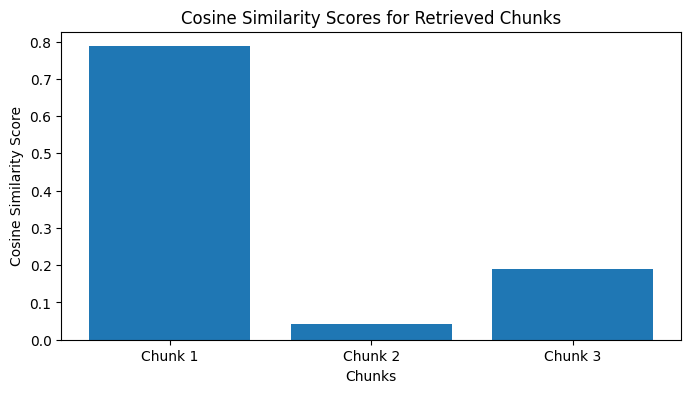

Chunk 1 score: 0.787
Chunk 2 score: 0.042
Chunk 3 score: 0.19


In [ ]:
import matplotlib.pyplot as plt
from sentence_transformers import util

query = "What are the main points in AI ethics?"

query_embedding = embedder.encode(query, convert_to_tensor=True)

scores = util.cos_sim(query_embedding, chunk_embeddings)[0]

scores_list = scores.cpu().tolist()

chunk_labels = []

for i in range(len(chunks)):
    chunk_labels.append(f"Chunk {i+1}")

plt.figure(figsize=(8, 4))
plt.bar(chunk_labels, scores_list)
plt.title("Cosine Similarity Scores for Retrieved Chunks")
plt.xlabel("Chunks")
plt.ylabel("Cosine Similarity Score")
plt.show()

for i, score in enumerate(scores_list, start=1):
    print(f"Chunk {i} score: {round(score, 3)}")